In [3]:
# numpy handles pretty much anything that is a number/vector/matrix/array
import numpy as np
# pandas handles dataframes
import pandas as pd
# matplotlib emulates Matlabs plotting functionality
import matplotlib.pyplot as plt
# seaborn is another good plotting library. In particular, I like it for heatmaps (https://seaborn.pydata.org/generated/seaborn.heatmap.html)
import seaborn as sns;
# stats models is a package that is going to perform the regression analysis
from statsmodels import api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
# os allows us to manipulate variables on out local machine, such as paths and environment variables
import os
# self explainatory, dates and times
from datetime import datetime, date
# a helper package to help us iterate over objects
import itertools

In [4]:
def x2fx(x, model='quadratic'):
  """Will create a quadratic, interaction and linear
  versions of our variable of interest

  Similar to the `x2fx()` function in Matlab.

  Written by Saullo G. P. Castro, from
  https://stackoverflow.com/questions/26574998/is-there-an-equivalent-function-for-x2fx-in-numpy

  Basically don't worry too much about how this func works. If I had to write it myself,
  it would look a lot worse than this.

  Args:
    x (np.array):
      Data set with columns as features (variables) that we 
      want to generate higher order terms for
    model (str):
      Determine linear, interaction, quadratic, purequadratic terms
 
  Returns:
    Array with higher order terms added as additional columns
  """
  from itertools import combinations as comb
  linear = np.c_[np.ones(x.shape[0]), x]
  if model == 'linear':
    return linear
  if model == 'purequadratic':
    return np.c_[linear, x**2]

  interaction = np.vstack([x[:,i]*x[:,j] for i, j in
                           comb(range(x.shape[1]), 2)]).T
    
  if model == 'interaction':
    return np.c_[linear, interaction]
  if model == 'quadratic':
    return np.c_[linear, interaction, x**2]

def standardise(data):
  """ Standardise/Normalise data to have zero mean and unit variance

  Args:
    data (np.array):
      data we want to standardise (usually covariates)

    Returns:
      Standardised data, mean of data, standard deviation of data
  """
  mu = np.mean(data, axis=0)
  sigma = np.std(data, axis=0)
  scaled = (data - mu) / sigma
  return scaled, mu, sigma

In [5]:
combined = pd.read_csv('combined.csv')
combined['Date'] = pd.to_datetime(combined['Date'], format='mixed', dayfirst=True)
combined.head()

,Unnamed: 0,Rainfall amount (millimetres),Date,Maximum temperature (Degree C),Daily global solar exposure (MJ/m*m),North Brisbane Bikeway Mann Park Windsor Cyclists Outbound,Jack Pesch Bridge Pedestrians Outbound,Story Bridge East Pedestrian Inbound,Kedron Brook Bikeway Lutwyche Pedestrians Outbound,Kedron Brook Bikeway Mitchelton Pedestrian Outbound,...,Story Bridge East Pedestrian Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Outbound,Story Bridge West Cyclists Inbound,Bicenntenial Bikeway,Story Bridge East Cyclists Inbound,Bishop Street Pedestrians Inbound,Story Bridge West Cyclists Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Inbound,Kedron Brook Bikeway Mitchelton Pedestrian Inbound,Schulz Canal Bridge Cyclists Inbound
0,0,0.0,2014-01-01,30.6,31.2,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,3333.0,0.0,NaN,0.0,NaN,NaN,92.0
1,1,0.0,2014-02-01,31.8,23.4,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,4863.0,0.0,NaN,0.0,NaN,NaN,123.0
2,2,1.0,2014-03-01,34.5,29.6,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,3905.0,0.0,NaN,0.0,NaN,NaN,77.0
3,3,0.0,2014-04-01,38.7,30.5,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,3066.0,0.0,NaN,0.0,NaN,NaN,57.0
4,4,0.0,2014-05-01,33.6,15.7,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,0.0,4550.0,0.0,NaN,0.0,NaN,NaN,92.0


In [6]:
combined.shape
# we have 1826 rows and 57 columns
# we need to remove rows with lots of na values, first determine the threshold based on the number of rows
threshold = combined.shape[0] - 300
combined_filtered = combined.dropna(axis=1, thresh=threshold)
print(combined_filtered.shape)
combined_filtered = combined_filtered.dropna(axis = 0)
print(combined_filtered.shape)
combined_filtered.head()

(1826, 25)
(1422, 25)


,Unnamed: 0,Rainfall amount (millimetres),Date,Maximum temperature (Degree C),Daily global solar exposure (MJ/m*m),Story Bridge East Pedestrian Inbound,Schulz Canal Bridge Cyclists Outbound,Story Bridge West Pedestrian Outbound,Bicentennial Bikeway Pedestrians Inbound,Story Bridge West Pedestrian Inbound,...,Bicentennial Bikeway Pedestrians Outbound,Story Bridge East Cyclists Outbound,Bicentennial Bikeway Cyclists Outbound,Story Bridge East Pedestrian Outbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Outbound,Story Bridge West Cyclists Inbound,Bicenntenial Bikeway,Story Bridge East Cyclists Inbound,North Brisbane Bikeway Mann Park Windsor Pedestrian Inbound,Schulz Canal Bridge Cyclists Inbound
169,169,0.0,2014-06-19,20.3,8.0,0.0,55.0,0.0,1630.0,0.0,...,1900.0,0.0,333.0,0.0,0.0,0.0,4223.0,0.0,0.0,60.0
170,170,5.8,2014-06-20,22.5,9.1,0.0,49.0,0.0,1170.0,0.0,...,1586.0,0.0,403.0,0.0,0.0,0.0,3619.0,0.0,0.0,45.0
171,171,0.0,2014-06-21,25.6,12.9,0.0,67.0,0.0,1289.0,0.0,...,1847.0,0.0,642.0,0.0,0.0,0.0,4423.0,0.0,0.0,72.0
172,172,5.2,2014-06-22,24.2,13.0,0.0,76.0,0.0,1542.0,0.0,...,2126.0,0.0,635.0,0.0,0.0,0.0,5023.0,0.0,0.0,82.0
173,173,0.2,2014-06-23,24.1,13.6,0.0,69.0,0.0,1862.0,0.0,...,2180.0,0.0,631.0,0.0,0.0,0.0,5329.0,0.0,0.0,74.0


In [7]:
train = combined_filtered[combined_filtered.Date < datetime(year=2017, month=1, day=1)]
val = combined_filtered[((combined_filtered.Date >= datetime(year=2017, month=1, day=1)) &
                        (combined_filtered.Date < datetime(year=2018, month=1, day=1)))]
test = combined_filtered[((combined_filtered.Date >= datetime(year=2018, month=1, day=1)) &
                          (combined_filtered.Date < datetime(year=2019, month=1, day=1)))]
print('num train = {}'.format(train.shape[0]))
print('val train = {}'.format(val.shape[0]))
print('test train = {}'.format(test.shape[0]))


## we are going to make our data more compledx

## I want to see the data as a csv
training_data = pd.DataFrame(train)
training_data.to_csv('training_data.csv')

num train = 888
val train = 276
test train = 258


Model 1 RMSE = 623.3791739360704
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     113.1
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          4.59e-118
Time:                        16:34:08   Log-Likelihood:                -6899.6
No. Observations:                 888   AIC:                         1.382e+04
Df Residuals:                     880   BIC:                         1.385e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        739.22

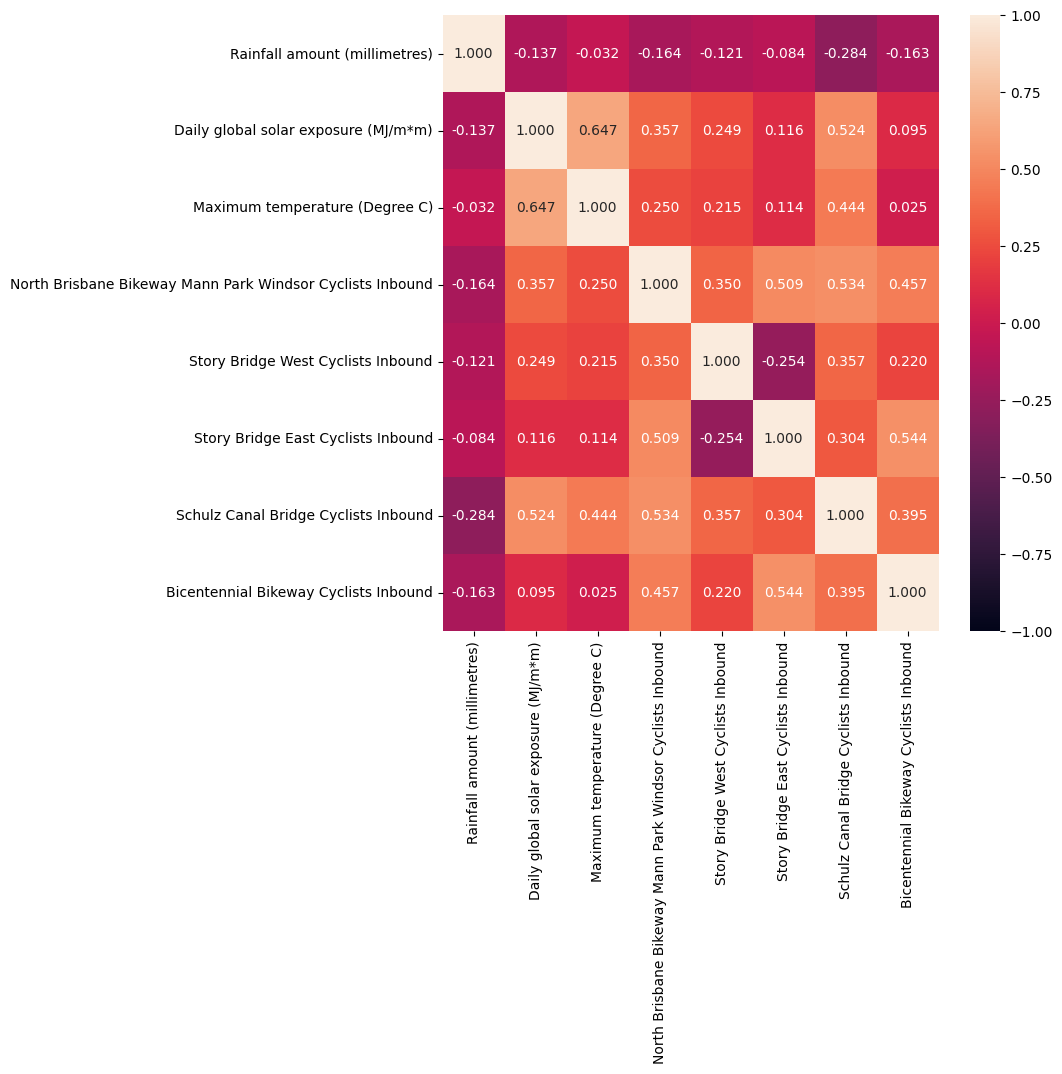

In [8]:
X_bom = ['Rainfall amount (millimetres)',
         'Daily global solar exposure (MJ/m*m)',
         'Maximum temperature (Degree C)']

# finding columns with cyclist inbound and appending it to X_bom
x_bbc = [x for x in train.columns.values if "Cyclists Inbound" in x]


#we are setting our response variable as BicentennialBikewayCyclistsInbound so we need to remove it from x_bbc
x_bbc.remove("Bicentennial Bikeway Cyclists Inbound")

X_variables = X_bom + x_bbc

Y_variable = 'Bicentennial Bikeway Cyclists Inbound'
Y_train = np.array(train[Y_variable], dtype=np.float64)
X_train = np.array(train[X_variables], dtype=np.float64)
X_train = sm.add_constant(X_train) # adding a column of all 1 to represent the y int

# repeating the exact same thing for our other data sets
Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)

Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

all_variables = X_variables + ['Bicentennial Bikeway Cyclists Inbound']

#from our training data set, take all of the varibales (response + predictors) and create a correlation map
corr_coeffs = train[all_variables].corr()
# plotting this correlation map
fig, ax = plt.subplots(figsize=(8,8))
ax = sns.heatmap(corr_coeffs, annot=True, fmt="1.3f", vmin=-1.0, vmax=1.0)

## Now we create the model 
model = sm.OLS(Y_train, X_train)
#learning the model
model_1 = model.fit()
# using the model to predict on the validation data
prediction_1 = model_1.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_1.predict(X_val)))))
print(model_1.summary())



In [22]:
## Adding complexities to the data
print(X_train.shape)

X_train_complex = x2fx(X_train)
X_val_complex = x2fx(X_val)
X_test_complex = x2fx(X_test)

## Training the model with the complicated data
model = sm.OLS(Y_train, X_train_complex)

## Learning the mode
model_fit = model.fit()

## Now we validate the model with the validation data
prediction_1 = model_fit.predict(X_val_complex)
print(model_fit.summary())

(888, 8)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     29.20
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          2.72e-121
Time:                        18:52:58   Log-Likelihood:                -6834.5
No. Observations:                 888   AIC:                         1.374e+04
Df Residuals:                     852   BIC:                         1.391e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        879.7158    256.658      3.428